## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Edward Christopher

**Date:** September 30, 2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
#**Q1.**
#1. What is the difference between regression and classification?
    # Regression aims to create a continous number and often relies on on a best fit line or curve throught datapoints. 
    # Regression outputs are judged based on Mean Squared Error, Root Mean Squared Error or R^2
    # Classification aims to classify inputs into discrete categories or labels. It relies on a decision boundry to seperate classes. 
    # Classification outputs are is judged on its accuracy, precision and F1-score
#2. What is a confusion table? What does it help us understand about a model's performance?
    # A confusion table is a test for classification models. 
    # It can be used on problems with many classifications, but the classic use case is a model with a binary output.
    # For a model with a binary output, the table has a 2x2 table with the y-axis being predicted value and x-axis being actual value
    # It has an output of 
    #   1. True Positive (correctly predicted it was Yes)
    #   2. False Positive (incorrectly predicted it was Yes) 
    #   3. False Negative (incorrectly predicted it was No) 
    #   4. True Negative (correctly predicted it was No) 
    # The table allows us to understand the model's failures better than a simple accuracy metric - we can understand if the model 
    # incorrectly identifies items as being true or false more often. Its output also can be transformed into an F1-score and can be 
    # scaled if there are more classifications.  
#3. What does the SSE quantify about a particular model?
    # The Sum of Squared Errors represents the difference between observed and predicted values. It is calculted by taking the sum of 
    # the squared difference of the observed and predicted values (sum((observed-predicted)^2)). SSE quantifies the acccuracy of the  
    # regression. The smaller the error, the more accurate the regression
#4. What are overfitting and underfitting? 
    # Overfitting is when a model is over-trained on the training data and is unable to preform well on test data. 
    # This often happens when the training data is small or noisy. It has low bias and high variance. 
    # Underfitting is when a model is under-trained and is neither accurate on the training or test data. 
    # It has high bias and low variance. 
#5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, 
#   improve model performance?
    # Splitting data into a training and testing set imporves model preformance because it helps reduce the risk of the model 
    # overfitting the data and allows for 'new' data to be used to test the data, improving the accuracy of tests. 
    # Choosing k on the test set improves model preformance because it measures the models real preformance and acts as a check against 
    # models that overfit. By using SSE with different k values, we can identify the k value that is most accuracte on new data
#6. With classification, we can report a class label as a prediction or a probability distribution over class labels. 
#   Please explain the strengths and weaknesses of each approach.
    # Prediction
        #Strengths: Simple to interpret, makes decision making easier downstream, saves space.
        #Weaknesses: Lacks nuance on model's confidence in prediction, rigid thresholds for predictions that are hard to change, 
        #            cannot use advanced evaluation methods, like Log Loss to check if the model is calibrated.
    # Probability distribution
        #Strengths: Quantifies uncertainly, allows for flexible thresholds to be required, can be evaluated with better tests
        #Weaknesses: Increased complexity for users downstream, larger storage requirements, needs to be calibrated

mine_type - Max:  5  Min:  1
voltage - Max:  0.999998727624942  Min:  0.197733878827493
height - Max:  1.0  Min:  0.0
soil - Max:  1.0  Min:  0.0
<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
(338, 4)
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.0

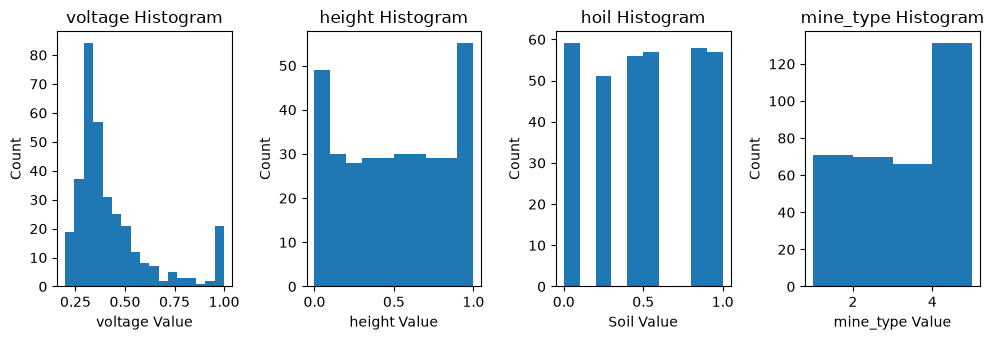


 k =  1
0.32130177514792896

 k =  2
0.40355029585798813

 k =  3
0.36627218934911243

 k =  4
0.3502958579881657

 k =  5
0.3165680473372781

 k =  6
0.34023668639053256

 k =  7
0.33609467455621306

 k =  8
0.33254437869822484

 k =  9
0.342603550295858

 k =  10
0.3591715976331361

 k =  11
0.34674556213017754

 k =  12
0.3526627218934911

 k =  13
0.34378698224852067

 k =  14
0.3443786982248521

 k =  15
0.34497041420118346

 k =  16
0.3497041420118343

 k =  17
0.3272189349112426

 k =  18
0.3431952662721894

 k =  19
0.3059171597633136

 k =  20
0.3224852071005918

 k =  21
0.31360946745562135

 k =  22
0.33254437869822484

 k =  23
0.3035502958579882

 k =  24
0.32603550295857986

 k =  25
0.31893491124260354

 k =  26
0.29230769230769227

 k =  27
0.33136094674556216

 k =  28
0.3047337278106509

 k =  29
0.30828402366863905

 k =  30
0.3076923076923077


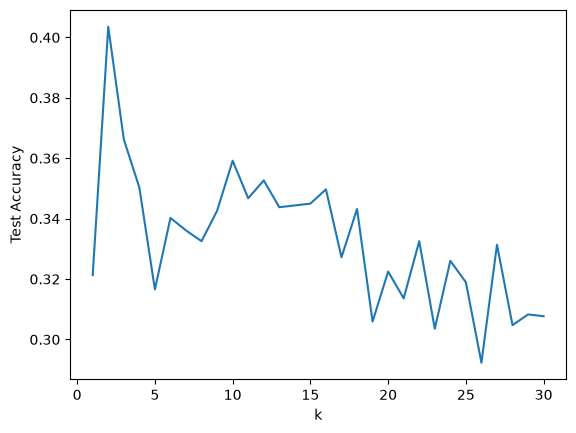

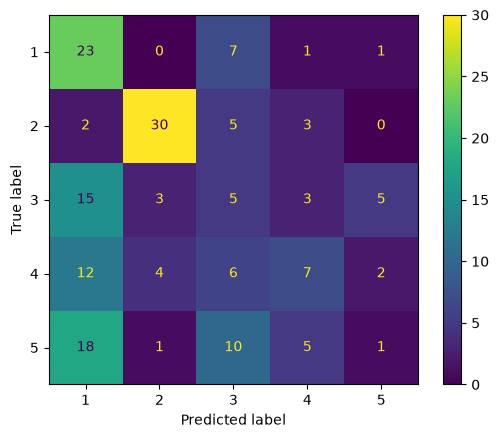

In [ ]:
#**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, 
# `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. 
# Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

# 1. Load the data. Perform some EDA, summarizing the target label and the features.

df = pd.read_csv('data/land_mines.csv')
df.head()
print('mine_type - Max: ', df['mine_type'].max(), ' Min: ', df['mine_type'].min(), )
print('voltage - Max: ', df['voltage'].max(), ' Min: ', df['voltage'].min(), )
print('height - Max: ', df['height'].max(), ' Min: ', df['height'].min(), )
print('soil - Max: ', df['soil'].max(), ' Min: ', df['soil'].min(), )
print(df.info())
print(df.shape)
#the data has no missing values and is made up of 338 rows and 4 columns 

print(df.describe())
i_values = ['voltage', 'height', 'soil', 'mine_type']
for i in i_values:
    print(df[i].nunique())
    print(df[i].value_counts())
    print(df.groupby(i).mean())

#no major take aways from the above loop

fig, axes = plt.subplots(1, 4, figsize=(10, 3.5))
df['voltage'].hist(bins= 'auto', grid=False, ax=axes[0])
axes[0].set(title="voltage Histogram", xlabel="voltage Value", ylabel="Count")
df['height'].hist(bins= 'auto', grid=False, ax=axes[1])
axes[1].set(title="height Histogram", xlabel="height Value", ylabel="Count")
df['soil'].hist(bins= 'auto', grid=False, ax=axes[2])
axes[2].set(title="hoil Histogram", xlabel="Soil Value", ylabel="Count")
df['mine_type'].hist(bins= 'auto', grid=False, ax=axes[3])
axes[3].set(title="mine_type Histogram", xlabel="mine_type Value", ylabel="Count")
plt.tight_layout()
plt.show()
# Target Lable: 
    # I believe that the target lable is mine_type
    # The max and min for mine_type are 5 and 1 respectively. 
# Features: 
    # I believe the three features/properties are voltage, height and soil
    # The max and min for height and soil are 1 and 0 respectivly and ~1 and ~0.2 respectively for voltage
    # Voltage is mainly concnetrated around 0.2-0.5
    # Height is evenly distributed in my opinion 
    # Soil is distributed  with gaps in between every 0.1 
    # Because the features are all between 0 and 1, I will not be scaling any of them.

# 2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be,
#    in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

#the following kNN methodology is from what Prof. Wright taught in DS 1001. I revisited my old Github repo and used that methodology.

features = df.drop('mine_type', axis=1)

target = df['mine_type']


# 3. Build a $k$-NN classifier. Explain how you select $k$.
i_values = range(1, 31)
j_values = range(1, 11)
accuracies = []
for i in i_values:
    print("\n k = ", i)
    n = 0
    for j in j_values:
        features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.5,)
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(features_train, target_train)
        target_predicted = knn.predict(features_test)
        n += accuracy_score(target_test, target_predicted)
    accuracies.append(n/10)
    print(n/10)

plt.plot(i_values, accuracies)
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.show()
# I did a nested for loop because i saw every run created a new output. I wanted to test each k value a few times to 
# create an average value that is more reflective of the accuracy. 
# Based on this output. 
# based on the printed info and graph, the peak of k is generally 2 or 3. I know k should be odd, so I will opt to have 3 be the k. 


# 4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. 
#    How accurate is it? Where is performance more or less accurate?
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.5,)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(features_train, target_train)
target_predicted = knn.predict(features_test)
ConfusionMatrixDisplay.from_predictions(target_test,target_predicted)
    # Based on the produced confusion matrix, it only got 62  out of 169 right overall. 
    # It fairly accurate when it predicted 2. 
    # It often wrongly predicted mine_typw as 1 or 3, with 67 of the mistakes being mispredicted 1 and 3s. 

# 5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. 
#    Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.
    # If someome really wanted to use this model, I would tell them only to trust the prediction when the output is 2 as that output 
    # had an accuracy rate >70%, higher than any other output. 
    # I would tell them that if you got any other output (1 or 3-5), belive that it has a chance to be 1, 3, 4 or 5. 
    # I would also advise them NOT to use this model as it is accurate only 36% of the time. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]